In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split 
from sklearn.metrics import classification_report, confusion_matrix
from IPython.display import display

from src.data_processing import clean_text
from src.bag_of_words import NumpyBagOfWords
from src.hyperopt import build_grid
from src.models_numpy.logistic_regression import LogisticRegression

df = pd.read_csv("../data/processed/dataset_kaggle_daigt_processed.csv", sep=";")

label_map = {label: i for i, label in enumerate(sorted(df['Label'].unique()))}
inv_label_map = {i: label for label, i in label_map.items()}
df['label_id'] = df['Label'].map(label_map)

print("A limpar textos...")
df['text_clean'] = df['Text'].apply(clean_text)

num_classes = len(label_map)
y_onehot = np.eye(num_classes)[df['label_id'].values]

X_train, X_val, y_train_oh, y_val_oh = train_test_split(
    df['text_clean'], y_onehot, test_size=0.2, random_state=42, stratify=df['label_id']
)

_, _, y_train_labels, y_val_labels = train_test_split(
    df['text_clean'], df['label_id'], test_size=0.2, random_state=42, stratify=df['label_id']
)

print(f"Treino: {len(X_train)} | Validação: {len(X_val)}")

A limpar textos...
Treino: 3076 | Validação: 769


In [3]:
param_grid_lr = {
    'max_words': [1000, 1500, 2000],
    'learning_rate': [0.01, 0.05, 0.1],
    'epochs': [500, 600]
}

resultados_lr = []

print("=== A Iniciar Grid Search: Regressão Logística ===")
for params in build_grid(param_grid_lr):
    print(f"\nA testar: {params}")
    inicio = time.time()
    
    bow = NumpyBagOfWords(max_words=params['max_words'])
    X_tr = bow.fit_transform(X_train)
    X_te = bow.transform(X_val)
    
    model = LogisticRegression(
        n_features=X_tr.shape[1], 
        n_classes=num_classes, 
        learning_rate=params['learning_rate'], 
        epochs=params['epochs']
    )
    
    history = model.fit(X_tr, y_train_oh, val_data=(X_te, y_val_oh), verbose=False)
    
    val_acc_final = history['val_acc'][-1]
    val_loss_final = history['val_loss'][-1]
    tempo_gasto = time.time() - inicio
    
    resultados_lr.append({
        'Max Words': params['max_words'],
        'Learning Rate': params['learning_rate'],
        'Epochs': params['epochs'],
        'Val Accuracy': val_acc_final,
        'Val Loss': val_loss_final,
        'Tempo (s)': round(tempo_gasto, 1)
    })
    print(f" -> Val Acc: {val_acc_final:.4f} | Val Loss: {val_loss_final:.4f} | Tempo: {tempo_gasto:.1f}s")

df_grid_lr = pd.DataFrame(resultados_lr).sort_values(by=['Val Accuracy', 'Val Loss'], ascending=[False, True])
display(df_grid_lr)

=== A Iniciar Grid Search: Regressão Logística ===

A testar: {'max_words': 1000, 'learning_rate': 0.01, 'epochs': 500}
 -> Val Acc: 0.7048 | Val Loss: 1.2598 | Tempo: 4.1s

A testar: {'max_words': 1000, 'learning_rate': 0.01, 'epochs': 600}
 -> Val Acc: 0.7100 | Val Loss: 1.2160 | Tempo: 5.0s

A testar: {'max_words': 1000, 'learning_rate': 0.05, 'epochs': 500}
 -> Val Acc: 0.7685 | Val Loss: 0.8540 | Tempo: 3.7s

A testar: {'max_words': 1000, 'learning_rate': 0.05, 'epochs': 600}
 -> Val Acc: 0.7763 | Val Loss: 0.8127 | Tempo: 4.5s

A testar: {'max_words': 1000, 'learning_rate': 0.1, 'epochs': 500}
 -> Val Acc: 0.7984 | Val Loss: 0.7068 | Tempo: 3.6s

A testar: {'max_words': 1000, 'learning_rate': 0.1, 'epochs': 600}
 -> Val Acc: 0.8049 | Val Loss: 0.6727 | Tempo: 4.1s

A testar: {'max_words': 1500, 'learning_rate': 0.01, 'epochs': 500}
 -> Val Acc: 0.7074 | Val Loss: 1.2590 | Tempo: 7.4s

A testar: {'max_words': 1500, 'learning_rate': 0.01, 'epochs': 600}
 -> Val Acc: 0.7126 | Val Lo

,Max Words,Learning Rate,Epochs,Val Accuracy,Val Loss,Tempo (s)
17,2000,0.10,600,0.807542,0.667501,9.8
11,1500,0.10,600,0.806242,0.668622,8.3
5,1000,0.10,600,0.804941,0.672655,4.1
16,2000,0.10,500,0.798440,0.702094,7.8
10,1500,0.10,500,0.798440,0.703133,7.1
4,1000,0.10,500,0.798440,0.706836,3.6
9,1500,0.05,600,0.784135,0.809812,8.3
15,2000,0.05,600,0.782835,0.808994,9.7
3,1000,0.05,600,0.776333,0.812666,4.5
8,1500,0.05,500,0.776333,0.851385,7.1


A treinar o Modelo LR (Words: 2000, LR: 0.1, Epochs: 750)...
Epoch 20/750 | Loss: 1.4372 Acc: 0.6860 | Val Loss: 1.4350 Val Acc: 0.6892
Epoch 40/750 | Loss: 1.3037 Acc: 0.7113 | Val Loss: 1.3085 Val Acc: 0.6996
Epoch 60/750 | Loss: 1.2036 Acc: 0.7256 | Val Loss: 1.2140 Val Acc: 0.7126
Epoch 80/750 | Loss: 1.1258 Acc: 0.7402 | Val Loss: 1.1409 Val Acc: 0.7217
Epoch 100/750 | Loss: 1.0634 Acc: 0.7526 | Val Loss: 1.0823 Val Acc: 0.7321
Epoch 120/750 | Loss: 1.0119 Acc: 0.7604 | Val Loss: 1.0343 Val Acc: 0.7412
Epoch 140/750 | Loss: 0.9686 Acc: 0.7637 | Val Loss: 0.9940 Val Acc: 0.7555
Epoch 160/750 | Loss: 0.9314 Acc: 0.7711 | Val Loss: 0.9596 Val Acc: 0.7594
Epoch 180/750 | Loss: 0.8990 Acc: 0.7760 | Val Loss: 0.9299 Val Acc: 0.7633
Epoch 200/750 | Loss: 0.8705 Acc: 0.7835 | Val Loss: 0.9038 Val Acc: 0.7672
Epoch 220/750 | Loss: 0.8450 Acc: 0.7877 | Val Loss: 0.8807 Val Acc: 0.7698
Epoch 240/750 | Loss: 0.8221 Acc: 0.7945 | Val Loss: 0.8600 Val Acc: 0.7724
Epoch 260/750 | Loss: 0.8012 Ac

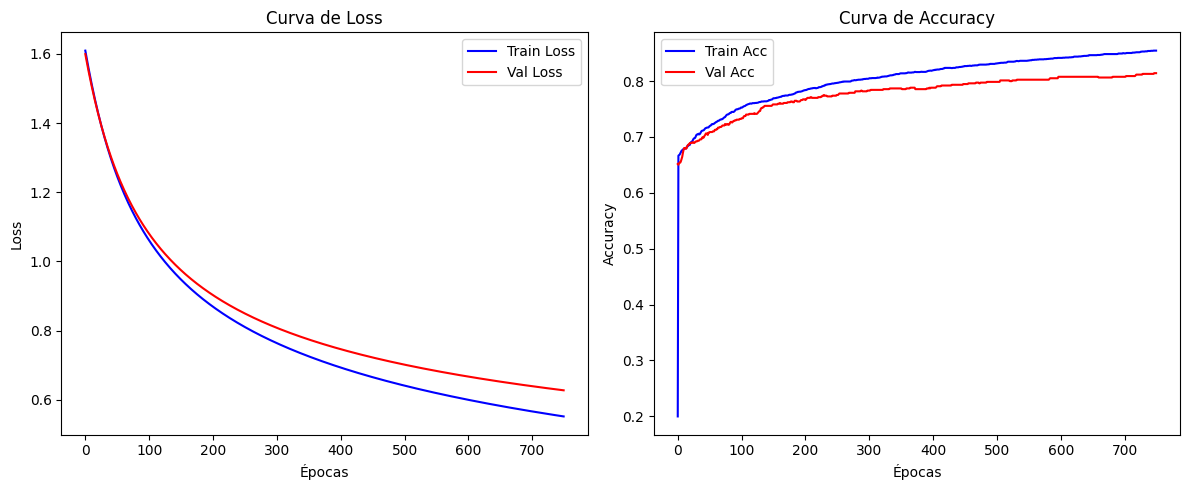

In [8]:
MELHOR_MAX_WORDS = 2000
MELHOR_LR = 0.1
MELHORES_EPOCAS = 750


print(f"A treinar o Modelo LR (Words: {MELHOR_MAX_WORDS}, LR: {MELHOR_LR}, Epochs: {MELHORES_EPOCAS})...")

bow_final = NumpyBagOfWords(max_words=MELHOR_MAX_WORDS)
X_train_final = bow_final.fit_transform(X_train)
X_val_final = bow_final.transform(X_val)

model_final = LogisticRegression(
    n_features=X_train_final.shape[1], 
    n_classes=num_classes, 
    learning_rate=MELHOR_LR, 
    epochs=MELHORES_EPOCAS
)

history_final = model_final.fit(X_train_final, y_train_oh, val_data=(X_val_final, y_val_oh), verbose=True)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_final['train_loss'], label='Train Loss', color='blue')
plt.plot(history_final['val_loss'], label='Val Loss', color='red')
plt.title('Curva de Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_final['train_acc'], label='Train Acc', color='blue')
plt.plot(history_final['val_acc'], label='Val Acc', color='red')
plt.title('Curva de Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


Relatório de Classificação Final (Logistic Regression):
              precision    recall  f1-score   support

   Anthropic       0.88      0.90      0.89       154
      Google       0.78      0.90      0.84       153
       Human       0.80      0.69      0.74       154
        Meta       0.87      0.80      0.83       154
      OpenAI       0.75      0.78      0.76       154

    accuracy                           0.81       769
   macro avg       0.82      0.81      0.81       769
weighted avg       0.82      0.81      0.81       769



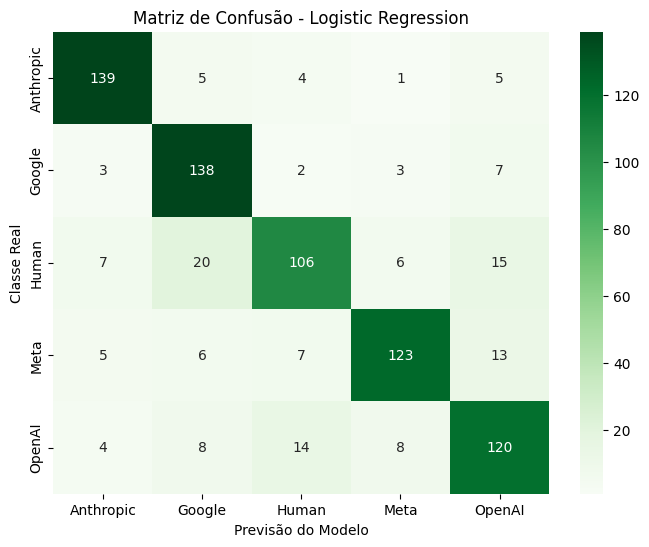

Modelo guardado com sucesso em '../models/logistic_regression_final.npz'


In [9]:
y_pred_final = model_final.predict(X_val_final)

nomes_classes = [inv_label_map[i] for i in range(num_classes)]

print("\nRelatório de Classificação Final (Logistic Regression):")
print(classification_report(y_val_labels, y_pred_final, target_names=nomes_classes))

# Matriz de Confusão
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_val_labels, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=nomes_classes, yticklabels=nomes_classes, cmap='Greens')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Classe Real')
plt.title('Matriz de Confusão - Logistic Regression')
plt.show()

import os
os.makedirs("../saved_models", exist_ok=True)
model_final.save("../saved_models/logistic_regression_final.npz")
bow_final.save("../saved_models/logistic_bow_model.pkl")
print("Modelo guardado com sucesso em '../models/logistic_regression_final.npz'")

In [11]:
print("Melhor Val Accuracy LR:", max(history_final['val_acc']))
print("Melhor Val Loss LR:", min(history_final['val_loss']))

Melhor Val Accuracy LR: 0.8140442132639792
Melhor Val Loss LR: 0.62764054034549
